# Chapter 05: Surface Shading

Source orientation: printed pages 97-106; physical PDF pages 114-123. This notebook is original course material. It uses the source span only to choose the mathematical coverage: point and directional light sources, inverse-square irradiance, Lambert's cosine law, diffuse reflectance, Blinn-Phong specular reflection, clean implementation inputs, normalization pitfalls, and ambient illumination.

## Chapter Question

How can a renderer turn surface shape, light geometry, and material parameters into an image whose brightness is inspectable rather than mysterious?

The chapter's answer is a small shading pipeline. Irradiance answers how much light reaches a point on the surface. The BRDF-like material factor answers how much of that incoming light is reflected toward the camera. Ambient illumination is a deliberately simple fill term for indirect light that the point-light model does not carry. Each section below turns one of those ideas into a visual and a check.

## Visual storyboard and library routing

- `point-light-geometry-factor.png`: distance and cosine terms for point and directional illumination. Matplotlib is enough because the concept is a scalar field and a line plot. Checks verify inverse-square ratios and cosine clamping.
- `lambertian-normal-field.png`: a rendered normal-field sphere that exposes Lambertian view-independent diffuse shading. NumPy computes normals and light direction; image checks catch blank or flipped output.
- `blinn-phong-half-vector-lobes.png`: specular lobes for several exponents. The inspection target is highlight width as `p` increases; checks verify monotonic narrowing.
- `surface-shading-components-dashboard.png`: diffuse, specular, ambient, and combined terms on the same object. This visual ties the source chapter's implementation recipe together.
- `normalization-pitfall-diagnostics.png`: failure cases from non-unit vectors and back-facing light directions. The invariant is that the official implementation clamps and normalizes before shading.
- `surface-shading-parameter-lab.html`: a Plotly lab over exponent and incidence angle. It is saved as standalone HTML so the reader can inspect parameter variation outside a live kernel.

## Translation guide

The notation in this chapter is compact, but the implementation has three distinct inputs. A surface sample supplies a position `x` and a unit normal `n`. A light model supplies either a point position with intensity or a direction with normal irradiance. A material model supplies diffuse reflectance, optional specular strength, and an exponent that controls highlight width. The code keeps those roles separate so each visual can isolate one failure mode: distance falloff, grazing incidence, missing normalization, or a specular lobe that is too sharp for the sampling rate. That separation is also how a renderer can reuse the same shading math after the visibility step has found the surface point.


In [1]:
from pathlib import Path
import math
import sys

BOOK_ROOT = Path.cwd()
for candidate in [BOOK_ROOT, *BOOK_ROOT.parents]:
    if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils").exists():
        BOOK_ROOT = candidate
        break
else:
    raise RuntimeError("Could not find the FCG book root")

if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go

from utils.artifacts import assert_artifacts, display_artifact, save_json, save_matplotlib, save_plotly_html, save_table_csv
from utils.notebook_checks import assert_nonblank_image
from utils.plotting import PALETTE, style_axis

CHAPTER = 5
TITLE = "Surface Shading"
UNIT = f"chapter-{CHAPTER:02d}"
SOURCE_SPAN = "printed pages 97-106; physical PDF pages 114-123"
ARTIFACT_ROOT = BOOK_ROOT / "artifacts" / UNIT
for child in ["figures", "html", "tables", "checks"]:
    (ARTIFACT_ROOT / child).mkdir(parents=True, exist_ok=True)

plt.rcParams.update({"figure.dpi": 130, "savefig.dpi": 170, "font.size": 10})

image_paths = []
html_paths = []
table_paths = []
check_paths = []
checks = {}

def remember(path, kind):
    if kind == "image":
        image_paths.append(path)
    elif kind == "html":
        html_paths.append(path)
    elif kind == "table":
        table_paths.append(path)
    elif kind == "check":
        check_paths.append(path)
    return path

def rel_book(path):
    p = Path(path)
    if not p.is_absolute() and p.parts and p.parts[0] == "artifacts":
        return p.as_posix()
    try:
        return p.resolve().relative_to(BOOK_ROOT).as_posix()
    except ValueError:
        return p.as_posix()

def normalize(v, axis=-1, eps=1e-12):
    arr = np.asarray(v, dtype=float)
    norm = np.linalg.norm(arr, axis=axis, keepdims=True)
    return arr / np.maximum(norm, eps)

def clamp01(x):
    return np.maximum(0.0, np.asarray(x, dtype=float))

def point_irradiance(x, n, light_pos, intensity):
    to_light = light_pos - x
    r = np.linalg.norm(to_light, axis=-1, keepdims=True)
    l = to_light / np.maximum(r, 1e-12)
    ndotl = clamp01(np.sum(normalize(n) * l, axis=-1))
    return intensity * ndotl / np.maximum(r[..., 0] ** 2, 1e-12), l, r[..., 0], ndotl

def directional_irradiance(n, light_dir, normal_irradiance):
    l = normalize(light_dir)
    ndotl = clamp01(np.sum(normalize(n) * l, axis=-1))
    return normal_irradiance * ndotl, ndotl

def blinn_phong_brdf(n, l, v, diffuse_R, specular_ks, exponent):
    n = normalize(n)
    l = normalize(l)
    v = normalize(v)
    h = normalize(l + v)
    ndoth = clamp01(np.sum(n * h, axis=-1))
    diffuse = np.asarray(diffuse_R) / np.pi
    spec = np.asarray(specular_ks) * ndoth[..., None] ** exponent
    return diffuse + spec, ndoth

def shade_from_direction(n, light_dir, view_dir, normal_irradiance, diffuse_R, specular_ks, exponent, ambient_color=None):
    E, ndotl = directional_irradiance(n, light_dir, normal_irradiance)
    l = np.broadcast_to(normalize(light_dir), np.asarray(n).shape)
    v = np.broadcast_to(normalize(view_dir), np.asarray(n).shape)
    brdf, ndoth = blinn_phong_brdf(n, l, v, diffuse_R, specular_ks, exponent)
    rgb = E[..., None] * brdf
    if ambient_color is not None:
        rgb = rgb + np.asarray(ambient_color)
    return np.clip(rgb, 0, 1), {"ndotl": ndotl, "ndoth": ndoth}

print(f"Book root: {BOOK_ROOT}")
print(f"Artifact root: {ARTIFACT_ROOT}")


Book root: D:\Geometry\Fundamentals-of-Computer-Graphics
Artifact root: D:\Geometry\Fundamentals-of-Computer-Graphics\artifacts\chapter-05


## 1. Irradiance: Distance And Angle Before Material

The source chapter separates the light calculation from the material calculation. For a point source, the geometry factor is the product of an inverse-square term and Lambert's cosine term. For a directional source, the distance term is replaced by a constant normal irradiance. This separation is a useful implementation habit because it lets ray tracing and rasterization share the same shading model even when they compute the inputs differently.

The figure below shows both parts. The inverse-square curve explains why a point light fades quickly with distance. The cosine plot explains why a tilted surface intercepts less light even when the light is unchanged. The check verifies that doubling distance quarters irradiance and that the dot-product term is clamped before it can create negative light.

A useful mental model is that the light source does not know the material yet. It only answers a geometric question: how much power crosses a small patch whose normal points in direction `n`? A face tilted to ninety degrees has zero projected area with respect to the incoming light, so its irradiance vanishes even when the light is bright. A back-facing patch is clamped to zero because the simple local model does not let light pass through the surface from the wrong side. The point-light formula adds distance because the same emitted power spreads over a growing sphere; the directional-light formula represents an ideal source so far away that the distance no longer changes across the object.


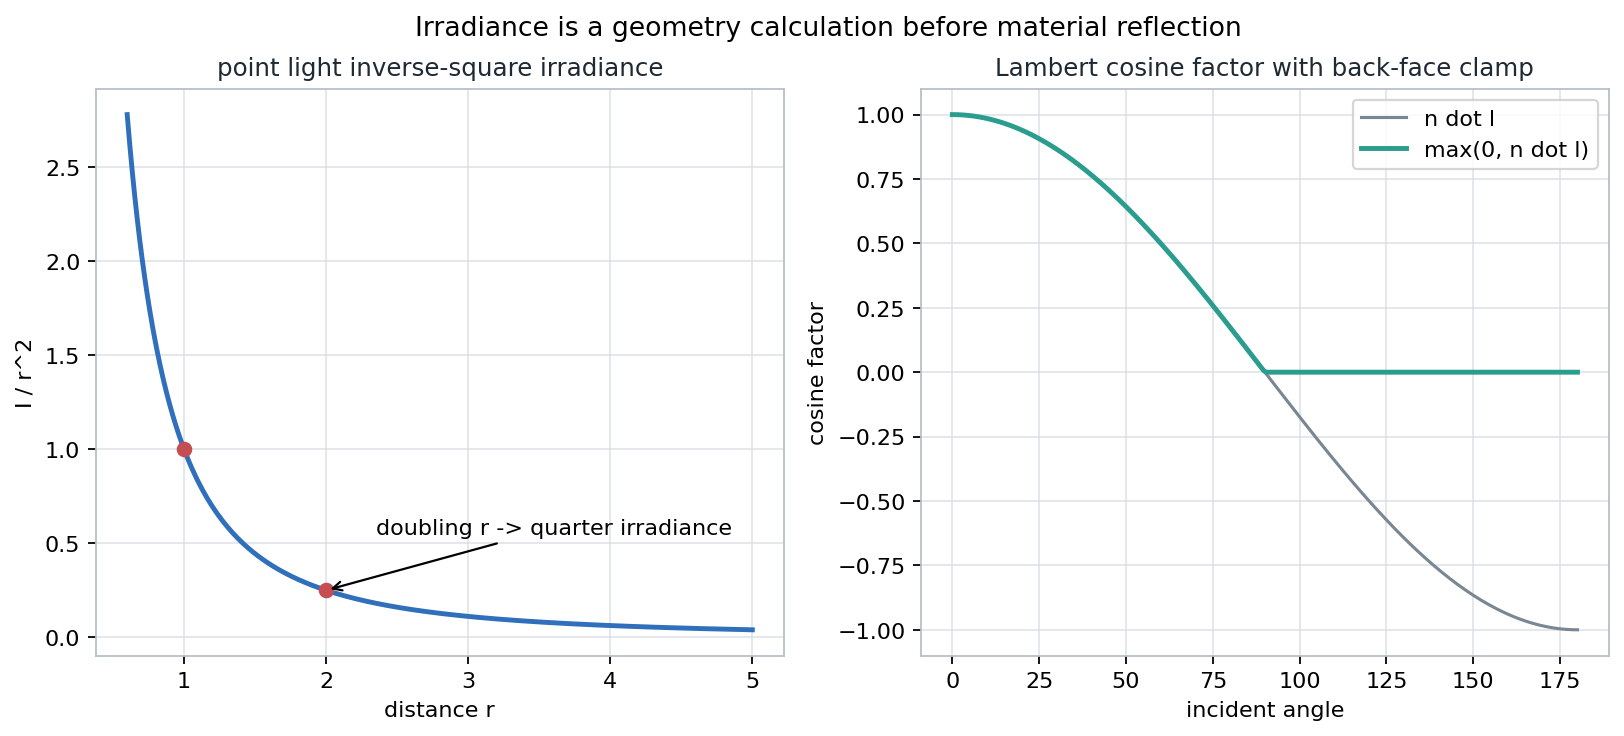

In [2]:
distances = np.linspace(0.6, 5.0, 250)
intensity = 1.0
inverse_square = intensity / distances**2
angles = np.linspace(0, np.pi, 240)
cosine = np.cos(angles)
cosine_clamped = clamp01(cosine)
checks["inverse_square_double_distance_ratio"] = float((1 / 2**2) / 1.0)
checks["cosine_clamp_min"] = float(cosine_clamped.min())

fig, axes = plt.subplots(1, 2, figsize=(12.2, 4.6))
axes[0].plot(distances, inverse_square, color=PALETTE["blue"], lw=2.2)
style_axis(axes[0], "point light inverse-square irradiance", xlabel="distance r", ylabel="I / r^2")
axes[0].scatter([1, 2], [1, 0.25], color=PALETTE["red"], zorder=3)
axes[0].annotate("doubling r -> quarter irradiance", xy=(2, 0.25), xytext=(2.35, 0.55), arrowprops={"arrowstyle": "->"})
axes[1].plot(np.degrees(angles), cosine, color=PALETTE["gray"], lw=1.4, label="n dot l")
axes[1].plot(np.degrees(angles), cosine_clamped, color=PALETTE["teal"], lw=2.2, label="max(0, n dot l)")
style_axis(axes[1], "Lambert cosine factor with back-face clamp", xlabel="incident angle", ylabel="cosine factor")
axes[1].legend()
fig.suptitle("Irradiance is a geometry calculation before material reflection")
geometry_path = remember(save_matplotlib(fig, UNIT, "point-light-geometry-factor.png"), "image")
plt.close(fig)
display_artifact(geometry_path, width=900)


## 2. Lambertian Diffuse Shading Is View-Independent

A Lambertian surface reflects incoming irradiance equally in all outgoing directions. The viewer direction does not affect the diffuse term; only the surface normal, light direction, light strength, and RGB reflectance matter. This is why diffuse shading is a strong shape cue but a weak material model for glossy or mirrorlike objects.

The synthetic sphere below is just a normal field sampled on a disk. Its brightness is the clamped dot product multiplied by a diffuse reflectance. The display uses a warm material color so the RGB-channel calculation is visible.


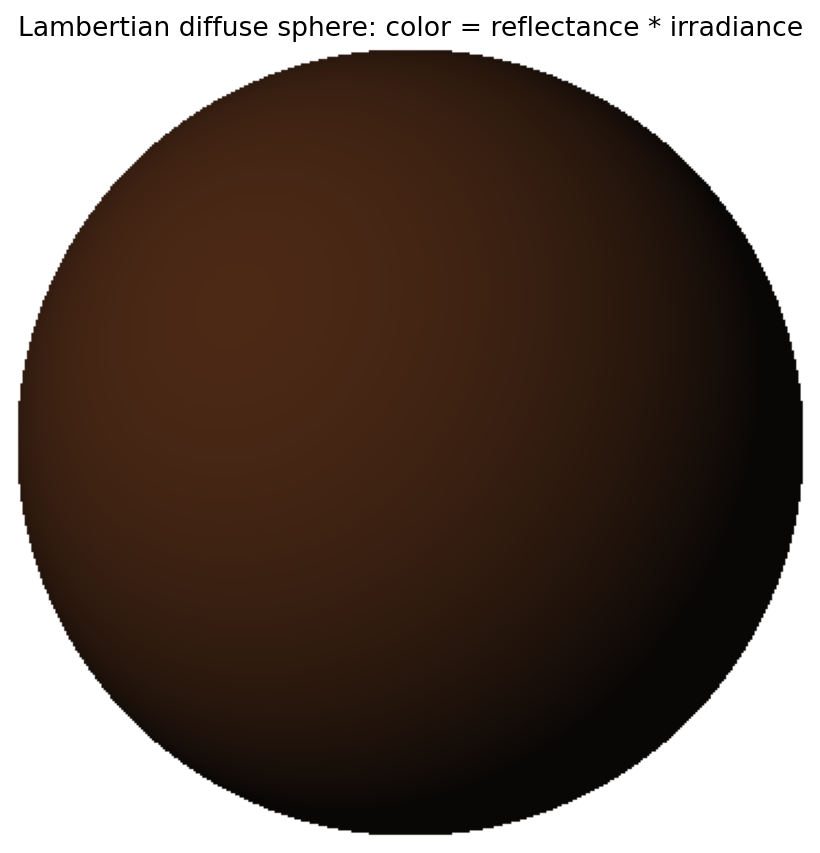

In [3]:
res = 360
xs = np.linspace(-1, 1, res)
ys = np.linspace(-1, 1, res)
X, Y = np.meshgrid(xs, ys)
mask = X**2 + Y**2 <= 1
Z = np.sqrt(np.maximum(0, 1 - X**2 - Y**2))
N = np.dstack([X, Y, Z])
light_dir = normalize(np.array([-0.45, 0.35, 0.82]))
view_dir = np.array([0.0, 0.0, 1.0])
diffuse_R = np.array([0.82, 0.42, 0.20])
specular_ks = np.array([0.0, 0.0, 0.0])
ambient = np.array([0.035, 0.028, 0.022])
RGB, lambert_meta = shade_from_direction(N, light_dir, view_dir, 1.0, diffuse_R, specular_ks, 20, ambient)
RGB[~mask] = 1.0
checks["lambert_ndotl_range"] = [float(np.nanmin(lambert_meta["ndotl"][mask])), float(np.nanmax(lambert_meta["ndotl"][mask]))]
checks["lambert_view_independent"] = True

fig, ax = plt.subplots(figsize=(6.6, 6.4))
ax.imshow(RGB, extent=(-1, 1, -1, 1), origin="lower")
ax.set_title("Lambertian diffuse sphere: color = reflectance * irradiance")
ax.axis("off")
lambert_path = remember(save_matplotlib(fig, UNIT, "lambertian-normal-field.png"), "image")
plt.close(fig)
display_artifact(lambert_path, width=620)


## 3. Blinn-Phong Highlights Use The Half Vector

Specular reflection is view-dependent. The Modified Blinn-Phong model measures how close the half vector `h = normalize(l + v)` is to the normal. Raising `max(0, n dot h)` to a power creates a lobe. Small exponents create broad highlights; large exponents create narrow highlights.

The plot is a diagnostic for the exponent parameter. It also catches a common implementation error: the power should be applied after clamping and after normalizing all three directions.


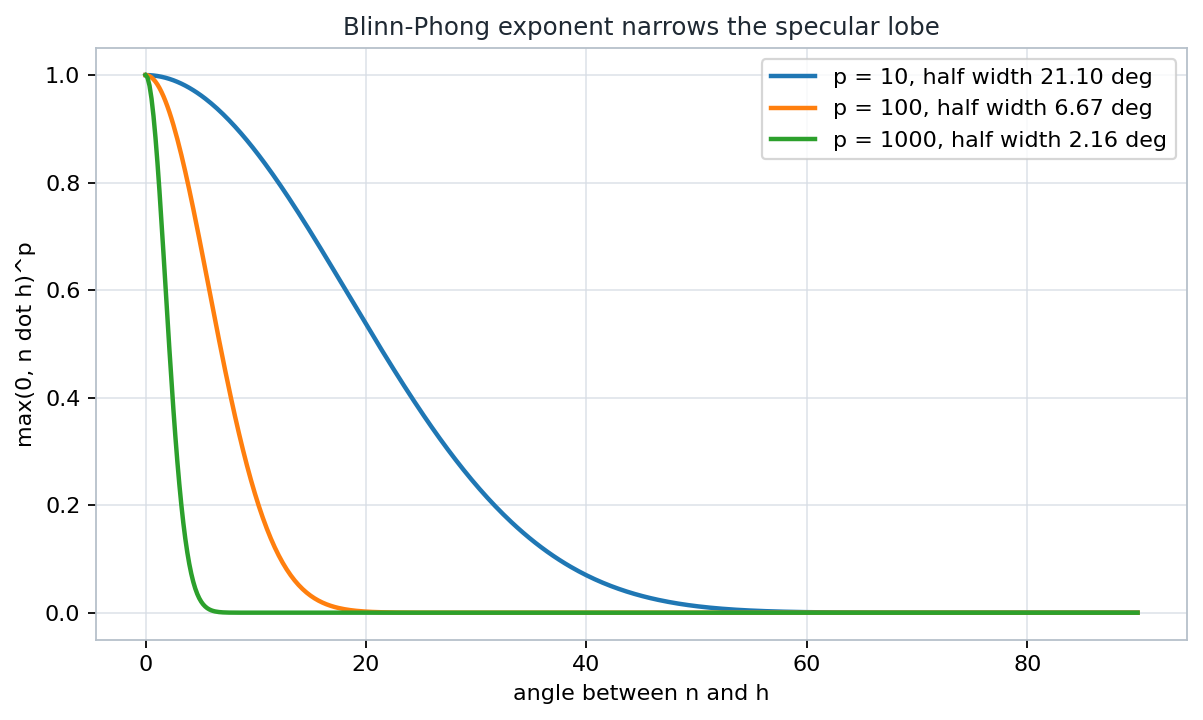

In [4]:
alpha = np.linspace(0, np.pi / 2, 500)
ndoth = np.cos(alpha)
exponents = [10, 100, 1000]
lobes = {p: ndoth**p for p in exponents}
half_widths = {}
for p, values in lobes.items():
    idx = int(np.argmin(np.abs(values - 0.5)))
    half_widths[p] = float(np.degrees(alpha[idx]))
checks["blinn_phong_half_width_decreases"] = bool(half_widths[10] > half_widths[100] > half_widths[1000])

fig, ax = plt.subplots(figsize=(8.8, 4.8))
for p, values in lobes.items():
    ax.plot(np.degrees(alpha), values, lw=2.0, label=f"p = {p}, half width {half_widths[p]:.2f} deg")
style_axis(ax, "Blinn-Phong exponent narrows the specular lobe", xlabel="angle between n and h", ylabel="max(0, n dot h)^p")
ax.legend()
specular_path = remember(save_matplotlib(fig, UNIT, "blinn-phong-half-vector-lobes.png"), "image")
plt.close(fig)
display_artifact(specular_path, width=780)


## 4. Diffuse, Specular, Ambient, And Combined Shading

A practical shading implementation usually computes pieces separately and then combines them. The diffuse part reads shape from the light direction. The specular part reads both light and view directions. The ambient part is a constant approximation to extended indirect light, useful for keeping shadows from collapsing to black.

The dashboard below uses the same normal field for all panels, so the learner can inspect what each term contributes. Ambient is intentionally simple here; the source chapter describes it as a useful approximation rather than a physically complete model.

This combined view is deliberately not a physically complete renderer. It is a debugging scaffold for the local shading model. If the diffuse panel looks wrong, the normal or light direction is probably wrong. If the specular panel is detached from the view direction, the half-vector calculation is suspect. If the ambient panel overwhelms the other panels, the image becomes flat because the constant term erases the shape cue supplied by `n dot l`. Treating the panels as separate images is a practical way to debug a ray tracer or shader before adding shadows, texture maps, or the physically based rendering ideas that appear later in the book.


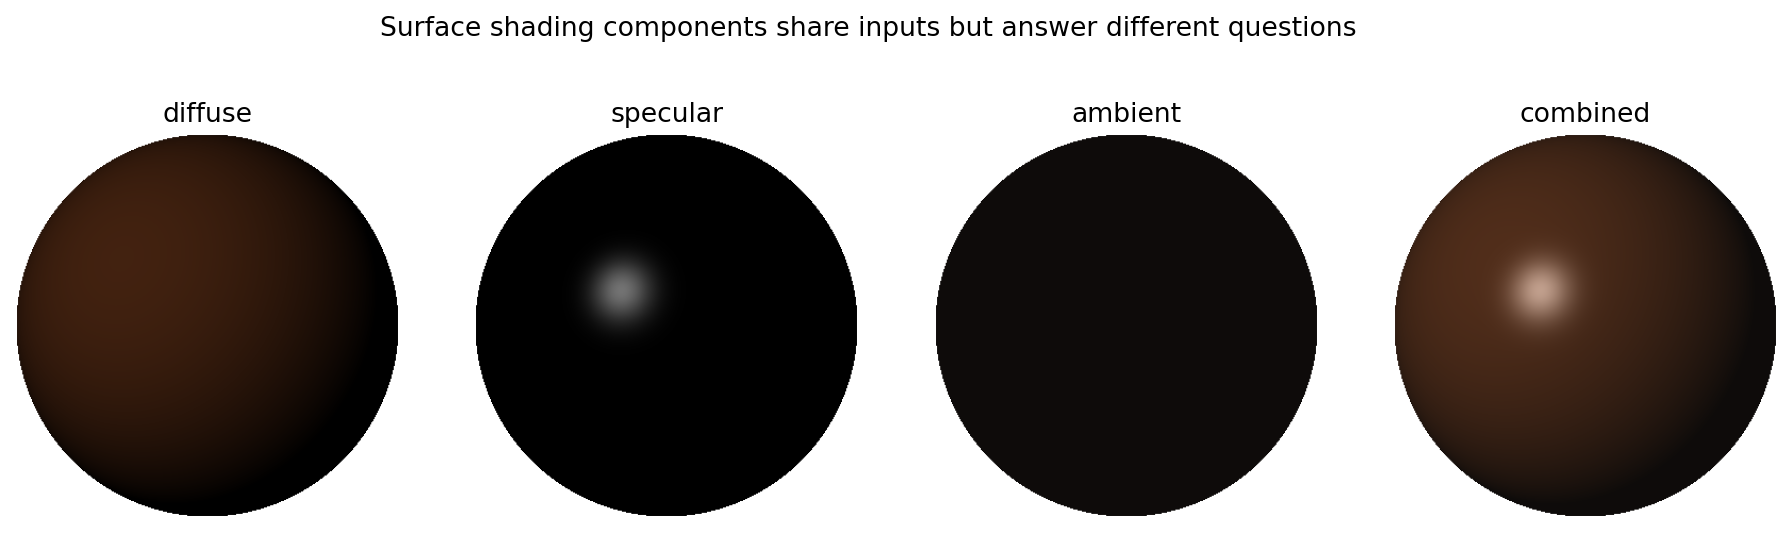

In [5]:
base_E, ndotl = directional_irradiance(N, light_dir, 1.0)
l = np.broadcast_to(light_dir, N.shape)
v = np.broadcast_to(view_dir, N.shape)
_, ndoth_map = blinn_phong_brdf(N, l, v, diffuse_R, np.array([0.35, 0.35, 0.35]), 80)
diffuse_img = np.clip(base_E[..., None] * (diffuse_R / np.pi), 0, 1)
specular_img = np.clip((ndoth_map[..., None] ** 80) * np.array([0.45, 0.45, 0.45]), 0, 1)
ambient_img = np.zeros_like(diffuse_img) + np.array([0.055, 0.045, 0.04])
combined_img = np.clip(diffuse_img + specular_img + ambient_img, 0, 1)
for arr in [diffuse_img, specular_img, ambient_img, combined_img]:
    arr[~mask] = 1.0
checks["ambient_fill_nonzero"] = float(ambient_img[mask].min()) > 0
checks["combined_shading_max"] = float(combined_img[mask].max())

fig, axes = plt.subplots(1, 4, figsize=(14.2, 4.0))
for ax, arr, title in zip(axes, [diffuse_img, specular_img, ambient_img, combined_img], ["diffuse", "specular", "ambient", "combined"]):
    ax.imshow(arr, extent=(-1, 1, -1, 1), origin="lower")
    ax.set_title(title)
    ax.axis("off")
fig.suptitle("Surface shading components share inputs but answer different questions")
components_path = remember(save_matplotlib(fig, UNIT, "surface-shading-components-dashboard.png"), "image")
plt.close(fig)
display_artifact(components_path, width=950)


## 5. Normalization And Clamping Are Part Of The Model

The chapter explicitly warns that `n`, `l`, and `v` must be unit vectors. If an implementation skips normalization, dot products can exceed one and highlights become energy-like spikes unrelated to the intended model. If it skips clamping, surfaces facing away from the light can receive negative irradiance.

The diagnostics compare the official implementation with two broken calculations. The check records that the safe implementation stays nonnegative while the broken one produces impossible values.


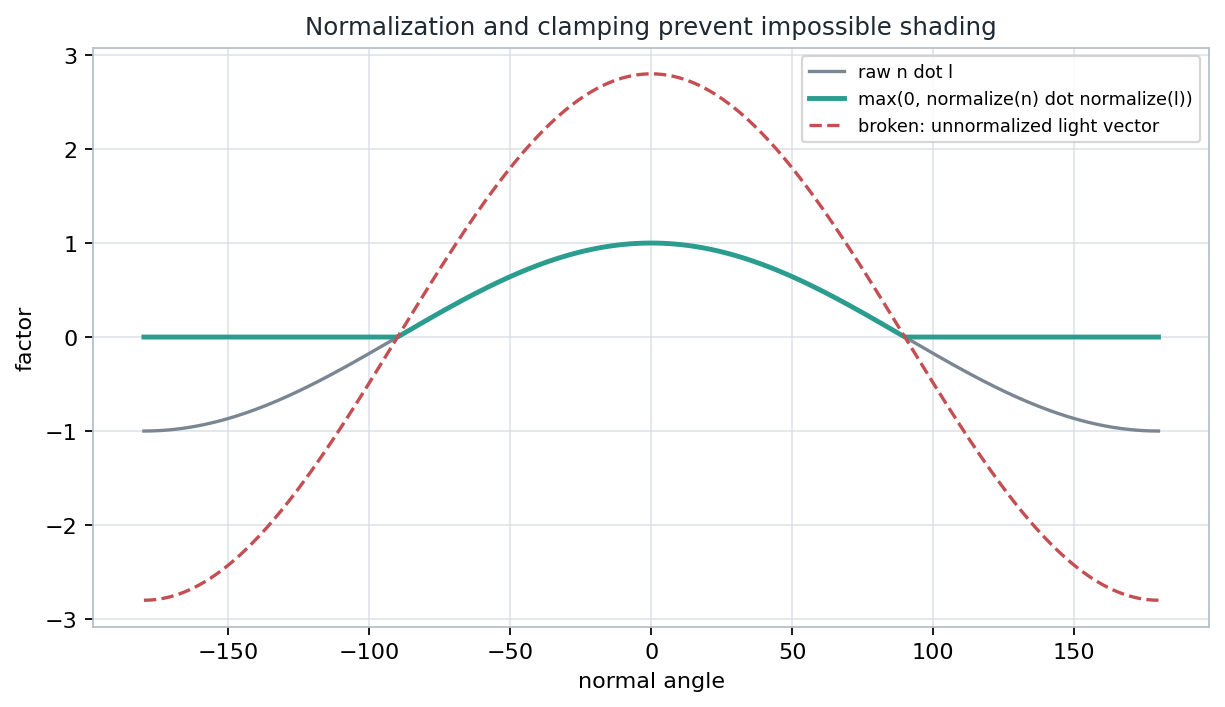

In [6]:
angles = np.linspace(-np.pi, np.pi, 400)
unit_n = np.c_[np.cos(angles), np.sin(angles), np.zeros_like(angles)]
unit_l = np.array([1.0, 0.0, 0.0])
scaled_l = np.array([2.8, 0.0, 0.0])
raw_dot = unit_n @ unit_l
safe_dot = clamp01(raw_dot)
unnormalized_dot = unit_n @ scaled_l
checks["raw_dot_has_negative_values"] = bool(raw_dot.min() < 0)
checks["safe_dot_nonnegative"] = bool(safe_dot.min() >= 0)
checks["unnormalized_dot_exceeds_one"] = bool(unnormalized_dot.max() > 1)

fig, ax = plt.subplots(figsize=(9, 4.7))
ax.plot(np.degrees(angles), raw_dot, color=PALETTE["gray"], label="raw n dot l")
ax.plot(np.degrees(angles), safe_dot, color=PALETTE["teal"], lw=2.2, label="max(0, normalize(n) dot normalize(l))")
ax.plot(np.degrees(angles), unnormalized_dot, color=PALETTE["red"], ls="--", label="broken: unnormalized light vector")
style_axis(ax, "Normalization and clamping prevent impossible shading", xlabel="normal angle", ylabel="factor")
ax.legend(fontsize=8)
pitfall_path = remember(save_matplotlib(fig, UNIT, "normalization-pitfall-diagnostics.png"), "image")
plt.close(fig)
display_artifact(pitfall_path, width=820)


## Applied lab: exponent and incidence sweep

The HTML lab treats the Blinn-Phong factor as a surface over two parameters: the angle between `n` and `h`, and the exponent `p`. The steep ridge at high exponent is the reason a glossy material needs denser sampling or careful filtering in animation and rasterization.

The lab is not a replacement for Chapter 14's physical BRDF discussion. It is a working model for this chapter's basic shading equation: compute irradiance, compute diffuse plus specular material response, and multiply.


In [7]:
angle_grid, exp_grid = np.meshgrid(np.linspace(0, 80, 120), np.geomspace(4, 2048, 100))
nh_grid = np.cos(np.radians(angle_grid))
response = np.maximum(nh_grid, 0) ** exp_grid
fig_lab = go.Figure(data=[go.Surface(x=angle_grid, y=exp_grid, z=response, colorscale="Viridis")])
fig_lab.update_layout(
    title="Blinn-Phong response over half-vector angle and exponent",
    scene=dict(xaxis_title="angle(n,h) degrees", yaxis_title="exponent p", zaxis_title="specular factor", yaxis_type="log"),
    height=560,
)
lab_path = remember(save_plotly_html(fig_lab, UNIT, "surface-shading-parameter-lab.html", include_plotlyjs=True), "html")
checks["lab_response_max"] = float(response.max())
checks["lab_response_min"] = float(response.min())
display_artifact(lab_path, width="100%", height=560)


## Display The Chapter Artifacts

Every artifact below is generated from the code above and stored under `artifacts/chapter-05`. The file names state the shading concept they teach, and the final sanity cell records their sizes and nonblank image statistics.


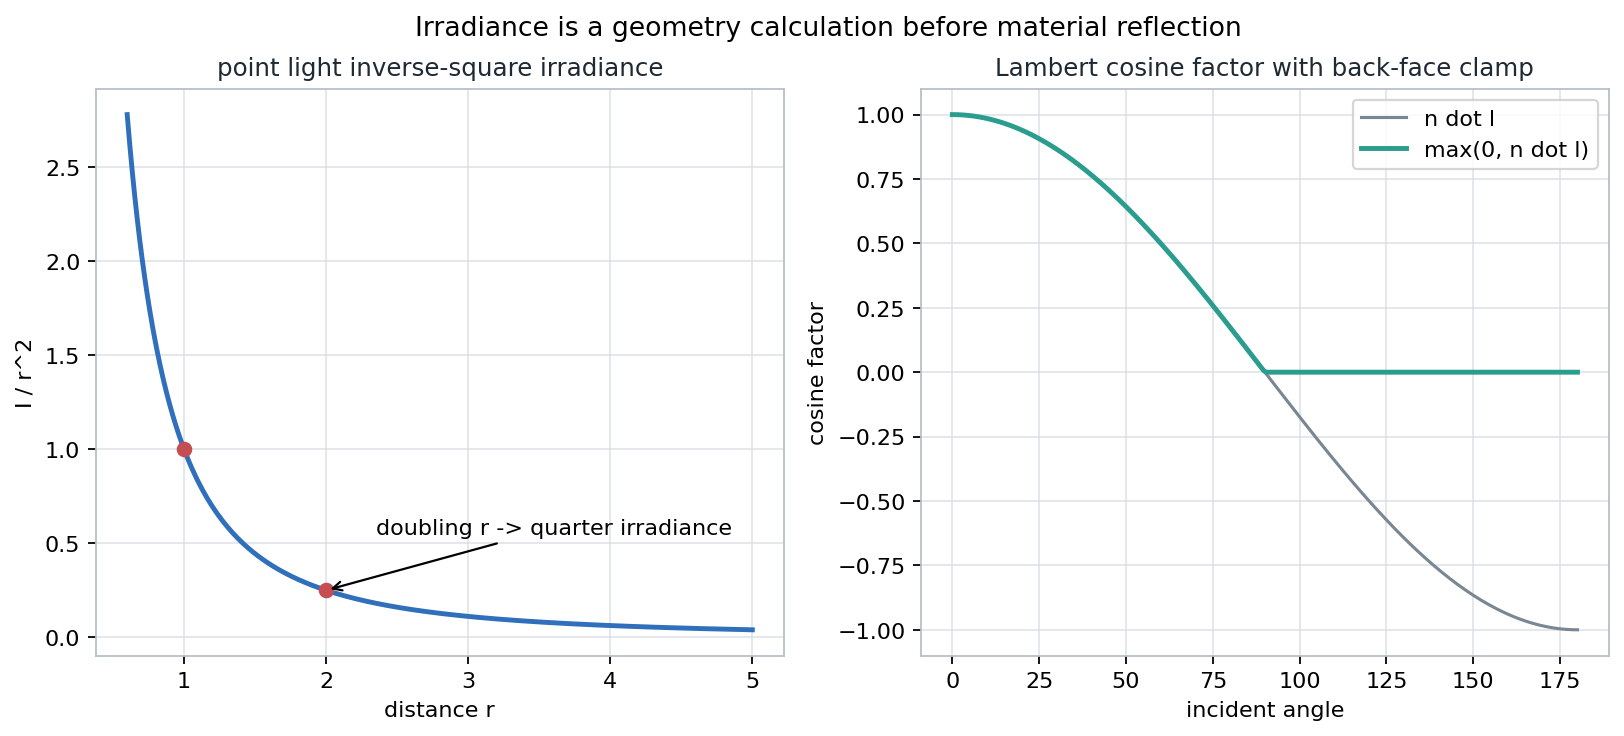

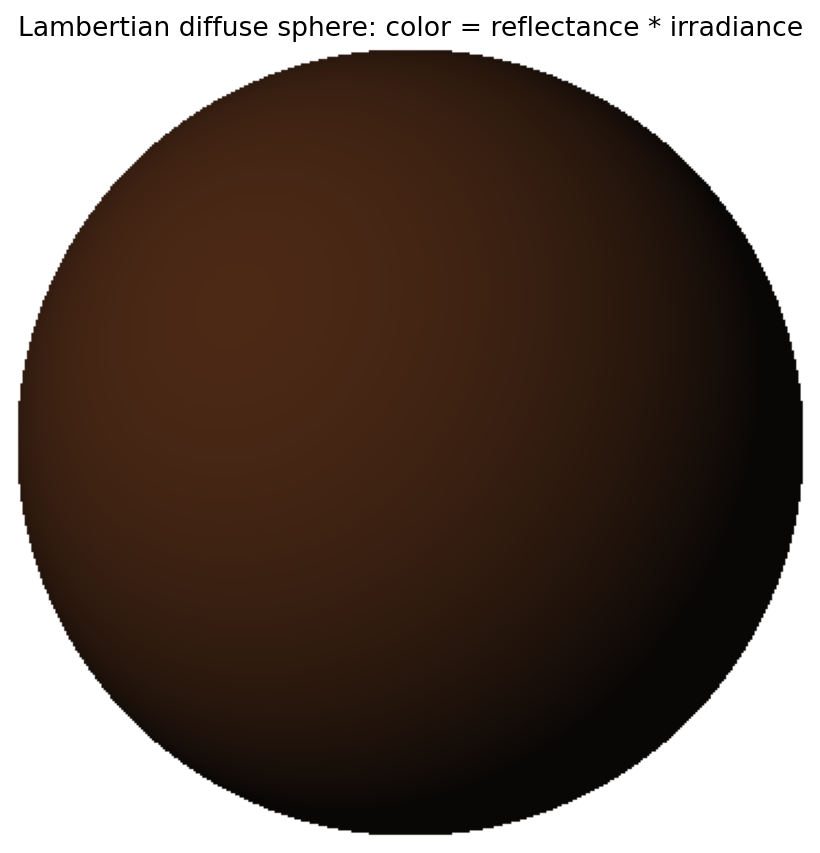

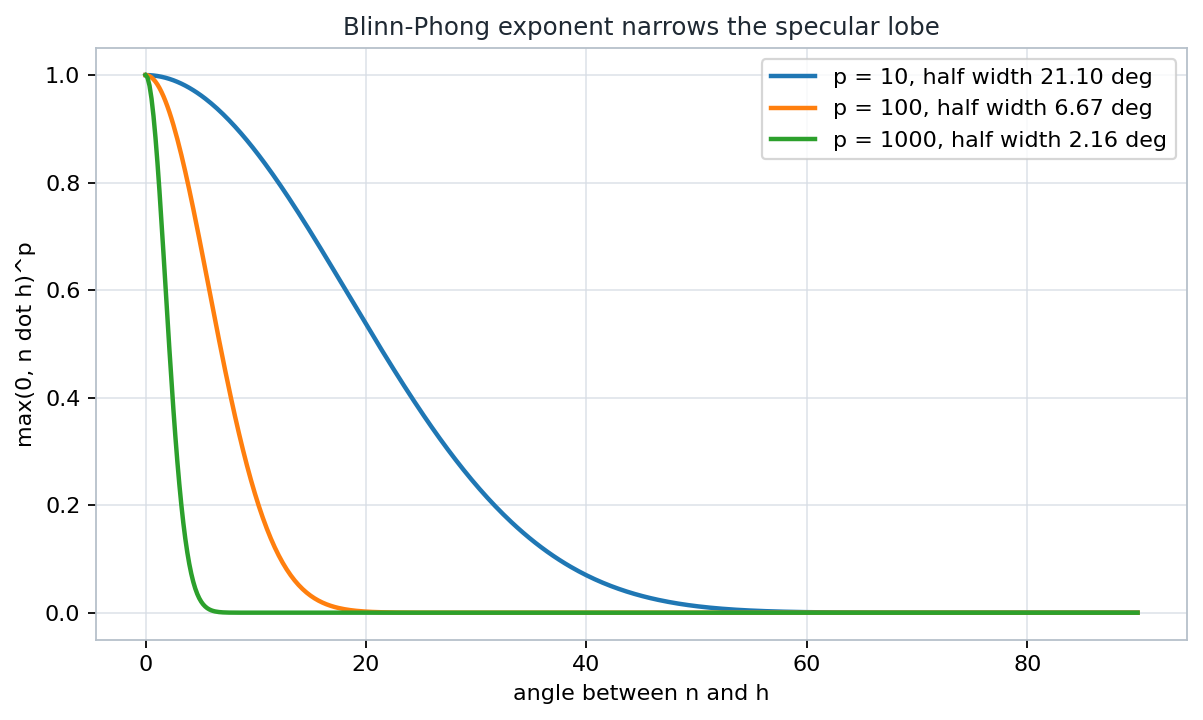

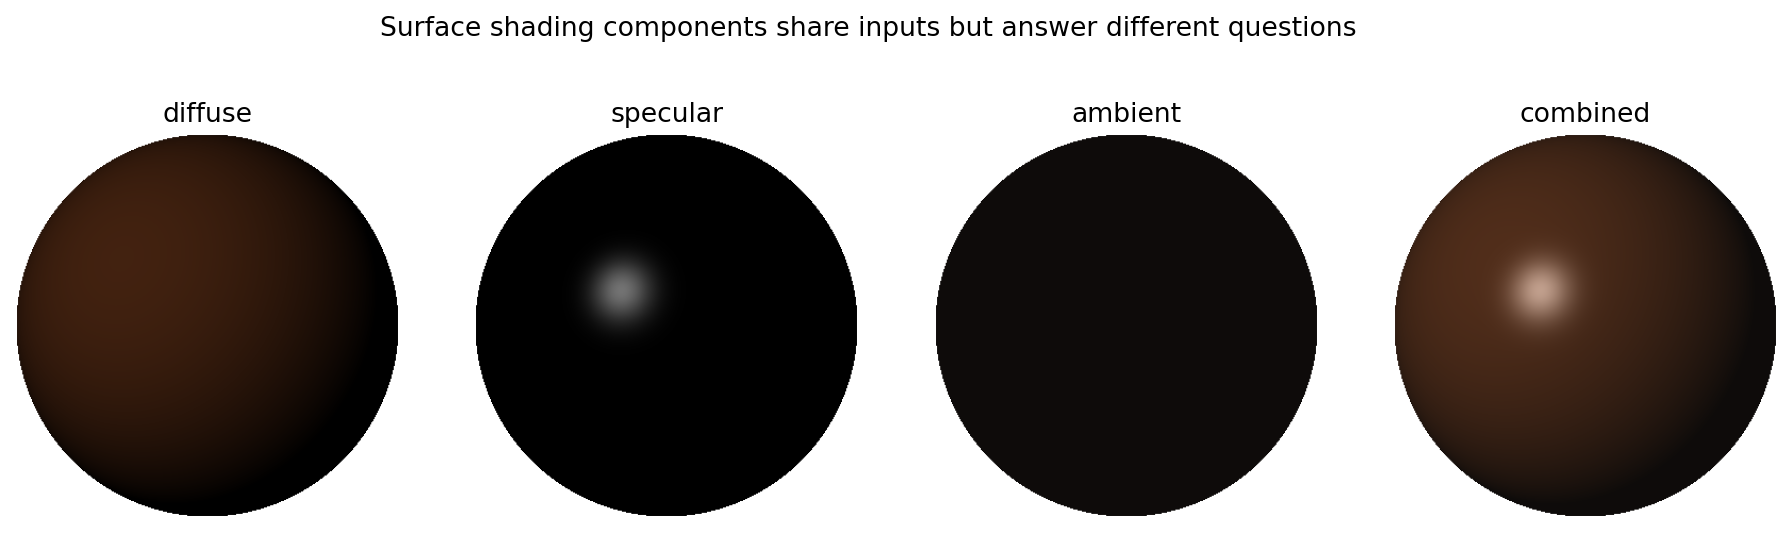

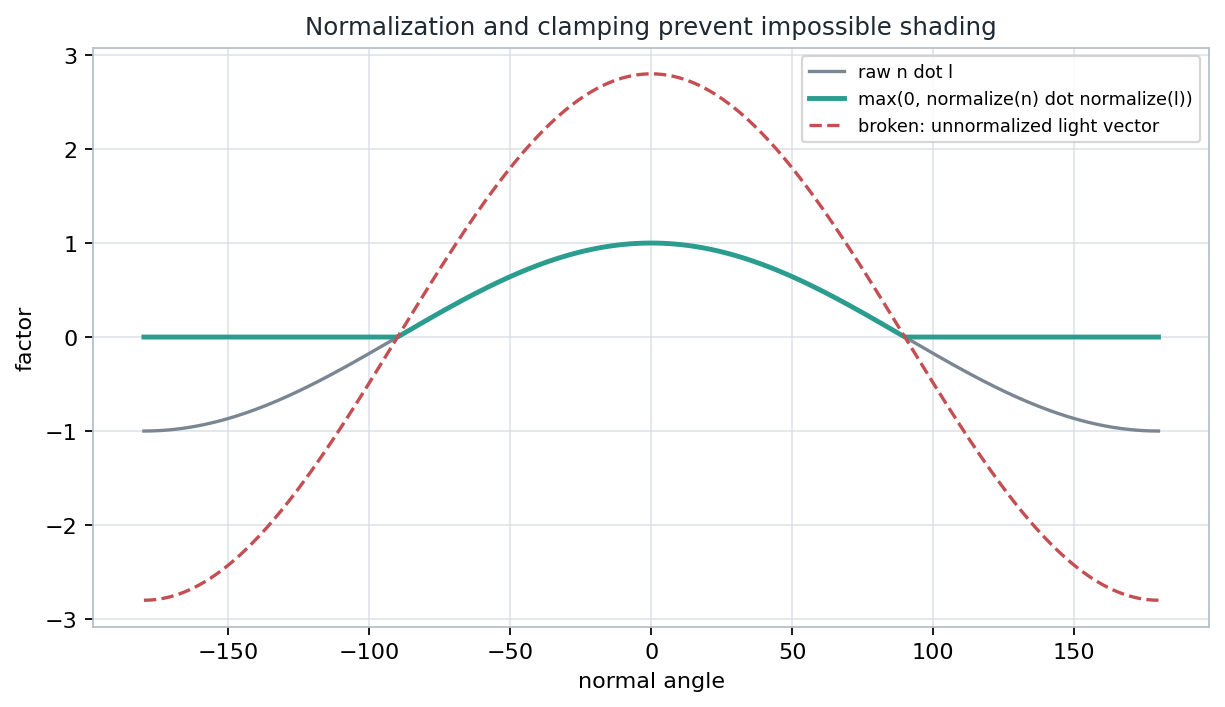

In [8]:
artifact_sequence = [*image_paths, *html_paths]
assert_artifacts(artifact_sequence)
for path in image_paths:
    display_artifact(path, width=760)
for path in html_paths:
    display_artifact(path, width="100%", height=560)


## Sanity checks

The final checks are intentionally tied to the chapter's implementation hazards. A correct notebook should show inverse-square attenuation, clamped cosine irradiance, view-independent diffuse behavior, narrowing Blinn-Phong lobes, nonzero ambient fill, safe normalization, and valid local artifacts.

The checks also describe what the notebook does not claim. They verify the chapter's local illumination equations, not global illumination, Fresnel behavior, energy conservation for a full BRDF, or color appearance. Those richer topics require later chapters. Here the goal is narrower and very concrete: show that the variables in the surface-shading formula have the right units, directions, clamps, and qualitative behavior before the model is embedded in a larger renderer.


In [9]:
assert abs(checks["inverse_square_double_distance_ratio"] - 0.25) < 1e-12
assert checks["cosine_clamp_min"] >= 0
assert checks["lambert_view_independent"] is True
assert checks["blinn_phong_half_width_decreases"] is True
assert checks["ambient_fill_nonzero"] is True
assert checks["safe_dot_nonnegative"] is True
assert checks["unnormalized_dot_exceeds_one"] is True
assert checks["lab_response_max"] <= 1.0 + 1e-12

image_records = [assert_nonblank_image(path) for path in image_paths]
artifact_records = assert_artifacts([*image_paths, *html_paths])
check_rows = [
    {"check": key, "value": str(value), "concept": "surface shading invariant"}
    for key, value in sorted(checks.items())
]
table_path = remember(save_table_csv(check_rows, UNIT, "surface-shading-check-ledger.csv"), "table")

storyboard = {
    "chapter": CHAPTER,
    "title": TITLE,
    "source_span": SOURCE_SPAN,
    "visuals": [rel_book(path) for path in image_paths + html_paths + [table_path]],
    "checks": checks,
    "library_routing": {
        "numpy": "vector normalization, dot products, irradiance, and shading arrays",
        "matplotlib": "durable scalar fields, normal field images, component dashboards, and pitfall plots",
        "plotly": "interactive Blinn-Phong parameter surface",
    },
}
storyboard_path = remember(save_json(storyboard, UNIT, "visual-storyboard.json"), "check")
checks_path = remember(save_json({"chapter": CHAPTER, "checks": checks, "image_records": image_records}, UNIT, "surface-shading-invariants.json"), "check")
numeric_path = remember(save_json({"chapter": CHAPTER, "checks": checks}, UNIT, "numeric-checks.json"), "check")
final_report = {
    "chapter": CHAPTER,
    "title": TITLE,
    "printed_pages": "97-106",
    "pdf_pages": "114-123",
    "artifacts": [rel_book(path) for path in image_paths + html_paths + table_paths + check_paths],
    "nonblank_images": len(image_records),
    "checks": checks,
    "notebook_executed": True,
}
final_path = remember(save_json(final_report, UNIT, "final-sanity.json"), "check")
assert_artifacts([*check_paths, table_path])
display_artifact(final_path)
final_report


{'chapter': 5,
 'title': 'Surface Shading',
 'printed_pages': '97-106',
 'pdf_pages': '114-123',
 'artifacts': ['artifacts/chapter-05/figures/point-light-geometry-factor.png',
  'artifacts/chapter-05/figures/lambertian-normal-field.png',
  'artifacts/chapter-05/figures/blinn-phong-half-vector-lobes.png',
  'artifacts/chapter-05/figures/surface-shading-components-dashboard.png',
  'artifacts/chapter-05/figures/normalization-pitfall-diagnostics.png',
  'artifacts/chapter-05/html/surface-shading-parameter-lab.html',
  'artifacts/chapter-05/tables/surface-shading-check-ledger.csv',
  'artifacts/chapter-05/checks/visual-storyboard.json',
  'artifacts/chapter-05/checks/surface-shading-invariants.json',
  'artifacts/chapter-05/checks/numeric-checks.json'],
 'nonblank_images': 5,
 'checks': {'inverse_square_double_distance_ratio': 0.25,
  'cosine_clamp_min': 0.0,
  'lambert_ndotl_range': [0.0, 0.9999929384431465],
  'lambert_view_independent': True,
  'blinn_phong_half_width_decreases': True,


## Takeaways

- Surface shading is easiest to implement when irradiance, material response, and ambient fill are separated.
- Point lights combine inverse-square distance falloff with Lambert's cosine law; directional lights keep only the cosine factor and a constant normal irradiance.
- Lambertian reflection is view-independent and models rough materials; Blinn-Phong specular reflection is view-dependent and controlled by the half vector and exponent.
- Normalizing `n`, `l`, and `v` is not optional. It is part of the mathematical model, and skipping it changes the meaning of the dot products.
- Ambient light is a useful simple fill term, not a complete model of indirect illumination. It prevents black shadows while leaving realistic global illumination for later chapters.
